## Manysearch interpretation mark 2

All files on farm in `/home/ctbrown/scratch3/2026-manysearch-many-metagenomes`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2026-manysearch-many-metagenomes'

# parquet files from 'sourmash gather' against 3,216 metagenomes
PROCESSED_PARQUET=BASE + '/manysearch/colton-40k.parquet'

## THRESHOLD_BP=20_000 # => default in parquet file is 3k

MIN_NUM_SAMPLES_PER_CONDITION=800

In [2]:
import polars as pl
import glob
import matplotlib.pyplot as plt

In [3]:
all_df = pl.read_parquet(PROCESSED_PARQUET)

In [4]:
print(f"loaded manysearch of {all_df['metag'].n_unique()} metagenomes.")

loaded manysearch of 41486 metagenomes.


In [5]:
all_df

species,metag,intersect_bp,weighted_bp
str,str,i64,i64
"""s__CAG-269 sp001916055""","""ERR4564322""",4000,7000
"""s__Hominicoprocola sp900317525""","""ERR4564322""",5000,10000
"""s__Methanocatella smithii""","""ERR4564322""",14000,17000
"""s__Oliverpabstia intestinalis""","""ERR4564322""",6000,8000
"""s__Megasphaera elsdenii""","""ERR4564322""",332000,727000
…,…,…,…
"""s__Hominisplanchenecus sp90521…","""ERR3405552""",3000,4000
"""s__UMGS1766 sp019420945""","""ERR3405552""",7000,7000
"""s__CAKTWY01 sp934630445""","""ERR3405552""",3000,3000


## Join with conditions

In [6]:
condition_df = (pl.read_csv('../../2025-sourmash-gather-to-vec/stool_idents_sat25_total100K.csv')
                .with_columns(metag=pl.col('acc'))
                .drop('acc')
               )
                             

condition_counts_df = (condition_df['condition']
                       .value_counts(name='condition_count')
                       .sort(by='condition_count', descending=True)
                       .filter(pl.col("condition_count") >= MIN_NUM_SAMPLES_PER_CONDITION)
                      )
condition_counts_df = condition_counts_df.with_row_index(name='condition_index')
condition_counts_df

condition_index,condition,condition_count
u32,str,u32
0,"""healthy""",18935
1,"""T2D""",2808
2,"""MS""",1909
3,"""IGT;MS""",1392
4,"""CAD;T2D""",832


In [7]:
join_df = all_df.join(condition_df, how='inner', on='metag')
join_df

species,metag,intersect_bp,weighted_bp,condition
str,str,i64,i64,str
"""s__CAG-269 sp001916055""","""ERR4564322""",4000,7000,"""CAD"""
"""s__Hominicoprocola sp900317525""","""ERR4564322""",5000,10000,"""CAD"""
"""s__Methanocatella smithii""","""ERR4564322""",14000,17000,"""CAD"""
"""s__Oliverpabstia intestinalis""","""ERR4564322""",6000,8000,"""CAD"""
"""s__Megasphaera elsdenii""","""ERR4564322""",332000,727000,"""CAD"""
…,…,…,…,…
"""s__Hominisplanchenecus sp90521…","""ERR3405552""",3000,4000,"""healthy"""
"""s__UMGS1766 sp019420945""","""ERR3405552""",7000,7000,"""healthy"""
"""s__CAKTWY01 sp934630445""","""ERR3405552""",3000,3000,"""healthy"""


In [8]:
def filter_combined_df(sub_df, frac, *, condition=None):
    """
    return grouped dataframe with filter based on frequency of species 'frac'.

    optionally select only metagenomes with condition 'condition'.
    """
    if condition:
        n1 = sub_df['metag'].n_unique()
        sub_df = sub_df.filter(pl.col("condition") == condition)
        n2 = sub_df['metag'].n_unique()
        print(f"filtered for {condition} - {n1} => {n2}")
        
    total = sub_df["metag"].n_unique()
    cutoff = int(frac * total + 1)

    group_df = sub_df.group_by('species') \
            .agg(pl.len(), pl.col('weighted_bp').median().alias('weight_med')) \
            .filter(pl.col("len") >= cutoff)
    group_df = group_df.sort("len", descending=True).with_columns(
        (pl.col("len") / total).alias("frequency")
    ).with_row_index(name="rank")

    return (cutoff, total, group_df)

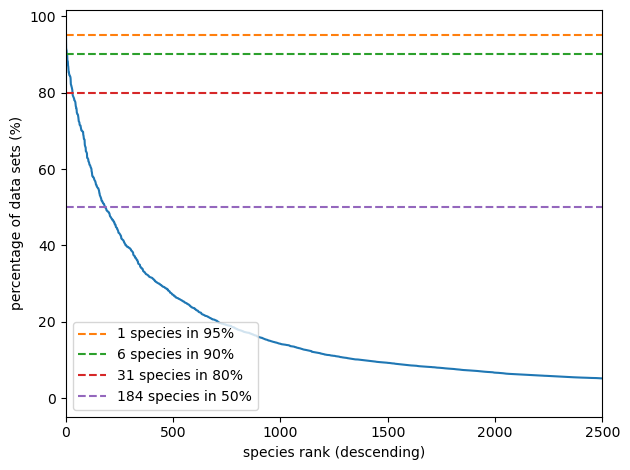

In [9]:
frac = 0
cutoff, total, group_df = filter_combined_df(join_df, frac)

len95 = len(group_df.filter(pl.col("frequency") >= 0.95))
len90 = len(group_df.filter(pl.col("frequency") >= 0.90))
len80 = len(group_df.filter(pl.col("frequency") >= 0.80))
len50 = len(group_df.filter(pl.col("frequency") >= 0.50))


plt.plot(group_df["rank"], group_df["frequency"]*100)
plt.plot([0, len(group_df)], [95, 95], '--', label=f'{len95} species in 95%')
plt.plot([0, len(group_df)], [90, 90], '--', label=f'{len90} species in 90%')
plt.plot([0, len(group_df)], [80, 80], '--', label=f'{len80} species in 80%')
plt.plot([0, len(group_df)], [50, 50], '--', label=f'{len50} species in 50%')

#plt.title("num core species at various thresholds in >= 1GB datasets")
plt.xlabel("species rank (descending)")
plt.ylabel("percentage of data sets (%)")
plt.legend(loc='lower left')
plt.xlim(0, 2500)
plt.tight_layout()

In [10]:
cutoff, total, group_df = filter_combined_df(join_df, 0.1, condition='healthy')

with pl.Config(tbl_rows=50):
    print(group_df)

filtered for healthy - 31160 => 18935
shape: (1_616, 5)
┌──────┬─────────────────────────────────┬───────┬────────────┬───────────┐
│ rank ┆ species                         ┆ len   ┆ weight_med ┆ frequency │
│ ---  ┆ ---                             ┆ ---   ┆ ---        ┆ ---       │
│ u32  ┆ str                             ┆ u32   ┆ f64        ┆ f64       │
╞══════╪═════════════════════════════════╪═══════╪════════════╪═══════════╡
│ 0    ┆ s__Escherichia coli             ┆ 18429 ┆ 93000.0    ┆ 0.973277  │
│ 1    ┆ s__Parabacteroides distasonis   ┆ 17180 ┆ 487000.0   ┆ 0.907314  │
│ 2    ┆ s__Phocaeicola vulgatus         ┆ 16953 ┆ 166000.0   ┆ 0.895326  │
│ 3    ┆ s__Blautia_A wexlerae           ┆ 16878 ┆ 105000.0   ┆ 0.891365  │
│ 4    ┆ s__Agathobacter rectalis        ┆ 16715 ┆ 645000.0   ┆ 0.882757  │
│ 5    ┆ s__Faecalibacterium longum      ┆ 16693 ┆ 161000.0   ┆ 0.881595  │
│ 6    ┆ s__Bacteroides uniformis        ┆ 16590 ┆ 600000.0   ┆ 0.876155  │
│ 7    ┆ s__Bacteroides thetaiot

## Plot frequency/abundance - do we see any high-abundance/low-frequency species?

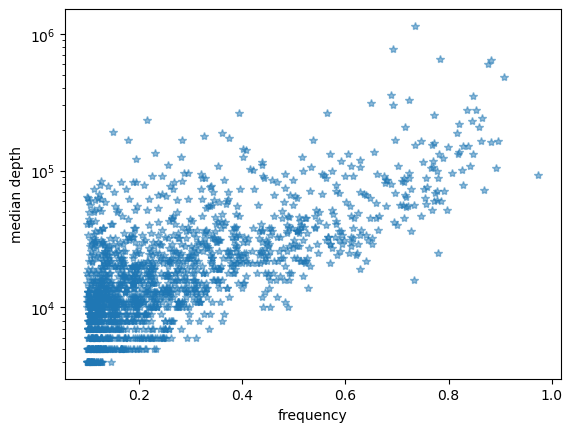

In [11]:
plt.plot(group_df['frequency'], group_df['weight_med'], '*', alpha=0.5)
plt.xlabel('frequency')
plt.ylabel('median depth')
plt.yscale('log')
#plt.xscale('log')

In [12]:
any90 = set()
any80 = set()


for condition in condition_counts_df['condition']:
    cutoff, total, group_df = filter_combined_df(join_df, frac, condition=condition)
    print(f"for condition {condition}, {total} samples.")

    sub_df = group_df.filter((pl.col("frequency") >= 0.8))
    any80.update(sub_df['species'].to_list())

    sub_df = group_df.filter((pl.col("frequency") >= 0.9))
    any90.update(sub_df['species'].to_list())
    
    #matches = sub_df.sample(11, seed=42)
    #sub_df
    
    with pl.Config(tbl_rows=-1):
        print(sub_df.select(["rank", "frequency", "species"]))

filtered for healthy - 31160 => 18935
for condition healthy, 18935 samples.
shape: (2, 3)
┌──────┬───────────┬───────────────────────────────┐
│ rank ┆ frequency ┆ species                       │
│ ---  ┆ ---       ┆ ---                           │
│ u32  ┆ f64       ┆ str                           │
╞══════╪═══════════╪═══════════════════════════════╡
│ 0    ┆ 0.973277  ┆ s__Escherichia coli           │
│ 1    ┆ 0.907314  ┆ s__Parabacteroides distasonis │
└──────┴───────────┴───────────────────────────────┘
filtered for T2D - 31160 => 2808
for condition T2D, 2808 samples.
shape: (17, 3)
┌──────┬───────────┬─────────────────────────────────┐
│ rank ┆ frequency ┆ species                         │
│ ---  ┆ ---       ┆ ---                             │
│ u32  ┆ f64       ┆ str                             │
╞══════╪═══════════╪═════════════════════════════════╡
│ 0    ┆ 0.984687  ┆ s__Bacteroides uniformis        │
│ 1    ┆ 0.984687  ┆ s__Bacteroides thetaiotaomicro… │
│ 2    ┆ 0.983974  ┆

## Do we see good-looking collector's curves?

(0.0, 100000000.0)

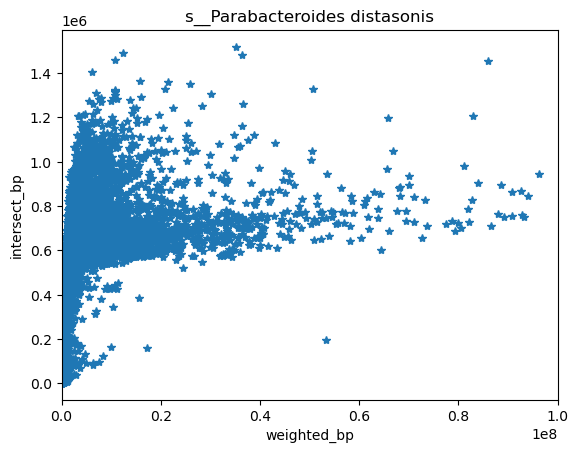

In [13]:
SPECIES = 's__Parabacteroides distasonis'

species_df = join_df.filter(pl.col('species') == SPECIES)

plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], '*')
plt.title(SPECIES)
plt.xlabel('weighted_bp')
plt.ylabel('intersect_bp')

plt.xlim(0, 1e8)

## Integrate saturation info

In [14]:
sat_df = (pl.read_parquet('/home/ctbrown/scratch3/2025-ccbaumler-wort-gathering/wort-sra-signature-saturation.parquet')
          .with_columns(metag=pl.col('signature'))
          .drop('signature')
         )
sat_df

filepath,novel_count,total_count,sequence_saturation,metag
str,i64,i64,f64,str
"""/group/ctbrowngrp/irber/data/w…",23507,397539,0.940869,"""SRR33867156"""
"""/group/ctbrowngrp/irber/data/w…",27896,308529,0.909584,"""ERR4022268"""
"""/group/ctbrowngrp/irber/data/w…",223,3174,0.929742,"""ERR3771976"""
"""/group/ctbrowngrp/irber/data/w…",20,40,0.5,"""ERR11996469"""
"""/group/ctbrowngrp/irber/data/w…",3185,26976,0.881932,"""ERR10755277"""
…,…,…,…,…
"""/group/ctbrowngrp/irber/data/w…",57128,286525,0.800618,"""SRR9934015"""
"""/group/ctbrowngrp/irber/data/w…",67307,409191,0.835512,"""SRR7588346"""
"""/group/ctbrowngrp/irber/data/w…",88275,942001,0.90629,"""SRR10432619"""


In [22]:
# try filtering at a given saturation point - sat_f
sat_f = 0.5
join2_df = join_df.join(sat_df.filter(pl.col('sequence_saturation') >= sat_f),
                        on='metag', how='inner')
print(f"filtered at saturation={sat_f}, num metags went from {join_df['metag'].n_unique()} => {join2_df['metag'].n_unique()}")

filtered at saturation=0.5, num metags went from 31160 => 28008


In [23]:
any90 = set()
any80 = set()


for condition in condition_counts_df['condition']:
    xx_df = join2_df.filter(pl.col('intersect_bp') >= 3_000)
    cutoff, total, group_df = filter_combined_df(xx_df, frac, condition=condition)
    print(f"for condition {condition}, {total} samples.")

    sub_df = group_df.filter((pl.col("frequency") >= 0.9))
    any90.update(sub_df['species'].to_list())
    

    sub_df = group_df.filter((pl.col("frequency") >= 0.8))
    any80.update(sub_df['species'].to_list())
    #matches = sub_df.sample(11, seed=42)
    #sub_df
    
    with pl.Config(tbl_rows=-1):
        print(sub_df.select(["rank", "frequency", "species"]))

filtered for healthy - 28008 => 17471
for condition healthy, 17471 samples.
shape: (25, 3)
┌──────┬───────────┬─────────────────────────────────┐
│ rank ┆ frequency ┆ species                         │
│ ---  ┆ ---       ┆ ---                             │
│ u32  ┆ f64       ┆ str                             │
╞══════╪═══════════╪═════════════════════════════════╡
│ 0    ┆ 0.977162  ┆ s__Escherichia coli             │
│ 1    ┆ 0.904985  ┆ s__Parabacteroides distasonis   │
│ 2    ┆ 0.890848  ┆ s__Phocaeicola vulgatus         │
│ 3    ┆ 0.88478   ┆ s__Blautia_A wexlerae           │
│ 4    ┆ 0.874192  ┆ s__Agathobacter rectalis        │
│ 5    ┆ 0.873848  ┆ s__Faecalibacterium longum      │
│ 6    ┆ 0.870929  ┆ s__Bacteroides uniformis        │
│ 7    ┆ 0.869899  ┆ s__Bacteroides thetaiotaomicro… │
│ 8    ┆ 0.854273  ┆ s__Fusicatenibacter saccharivo… │
│ 9    ┆ 0.851583  ┆ s__Blautia_A faecis             │
│ 10   ┆ 0.84935   ┆ s__Faecalibacterium duncaniae   │
│ 11   ┆ 0.843169  ┆ s__Roseb